Import Libraries

In [18]:
# Suppress warnings
import warnings
warnings.simplefilter(action="ignore")

# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display tools
from IPython.display import display

# Modeling and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, mean_squared_error, r2_score,
    roc_auc_score, roc_curve, classification_report, precision_score, recall_score
)

# Preprocessing
from sklearn.preprocessing import scale, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

# Feature selection
from sklearn.feature_selection import RFE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Statsmodels
import statsmodels.api as sm


Import Dataset

Data Preprocessing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Max Age: 81 | Min Age: 21


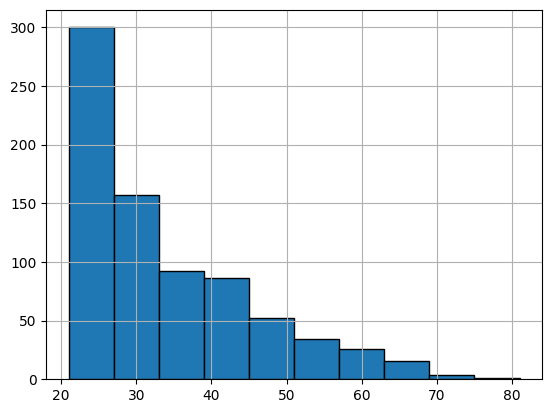

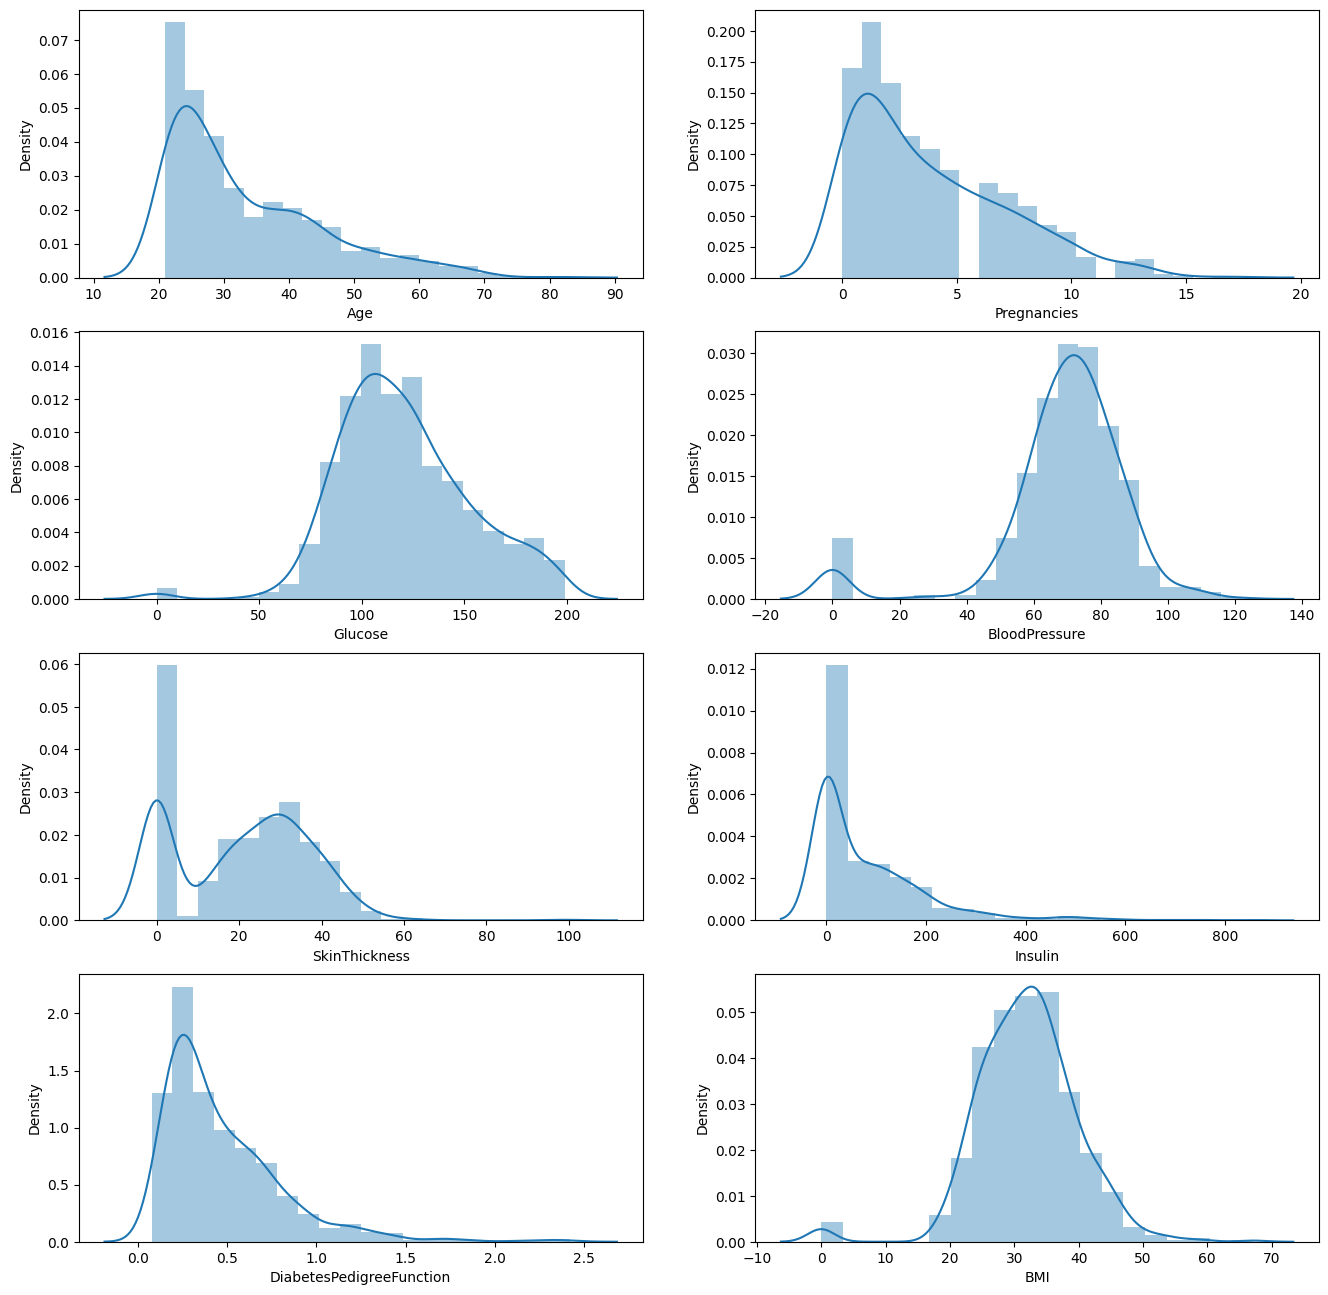

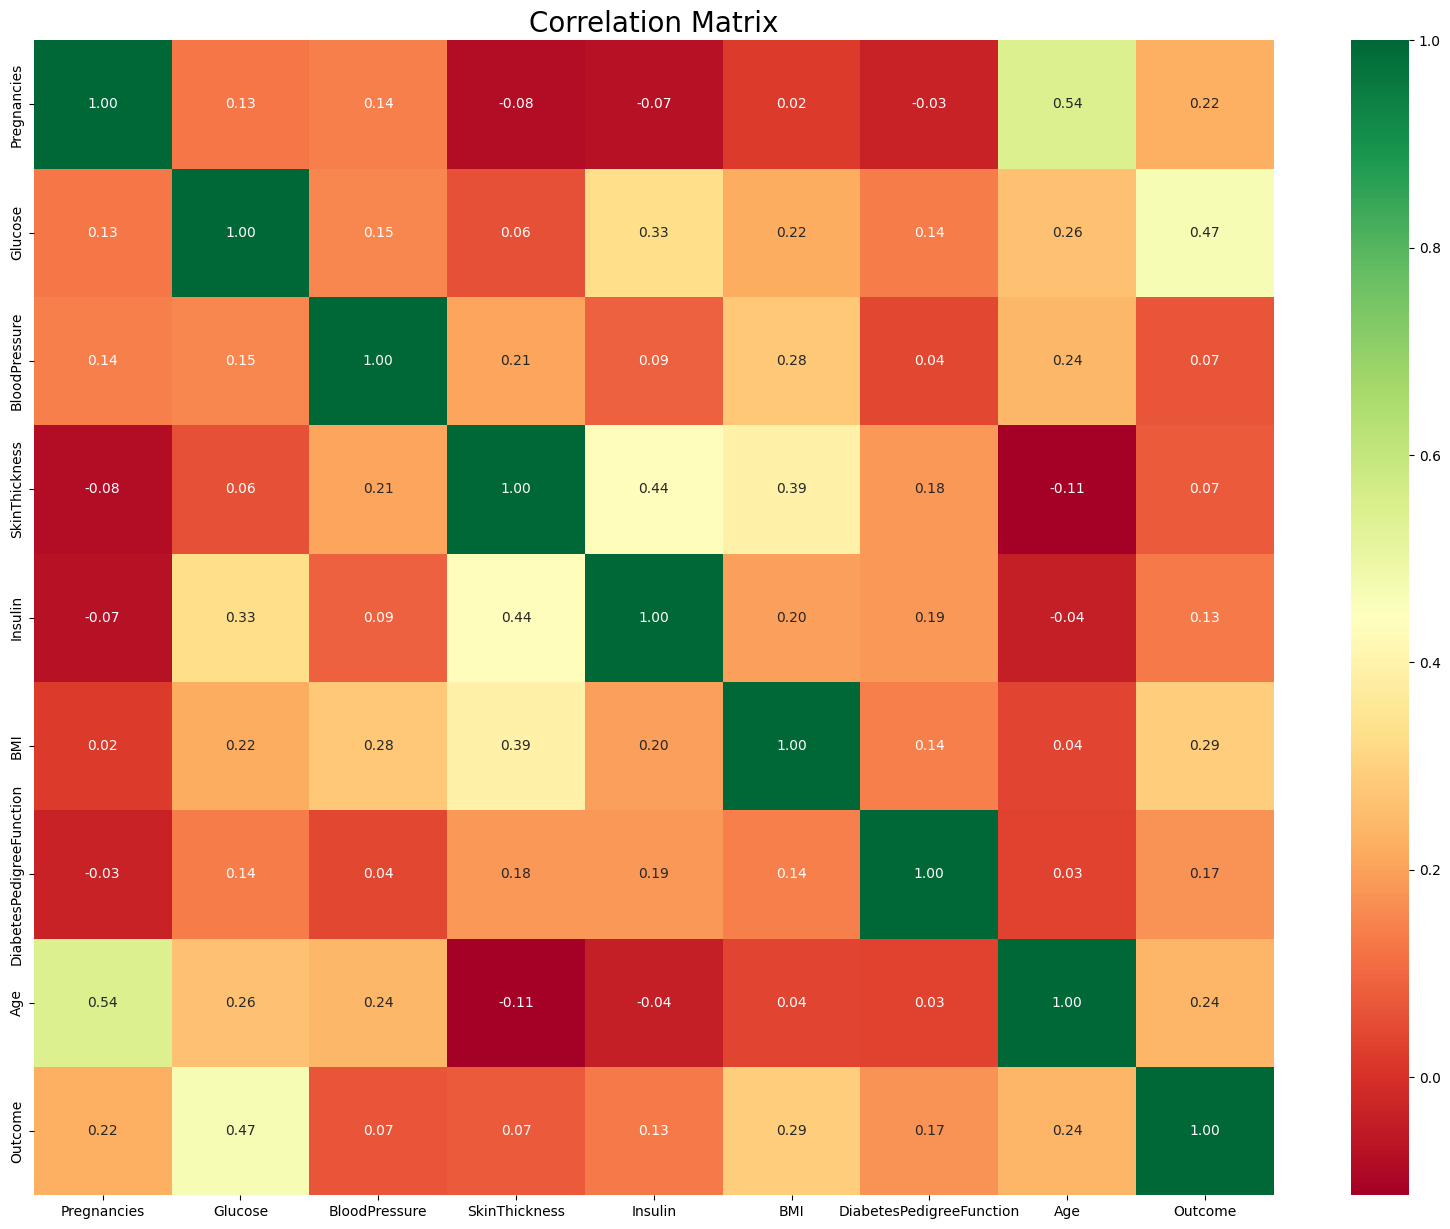

Pregnancies yes
Glucose no
BloodPressure yes
SkinThickness yes
Insulin yes
BMI yes
DiabetesPedigreeFunction yes
Age yes
Outcome no


0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

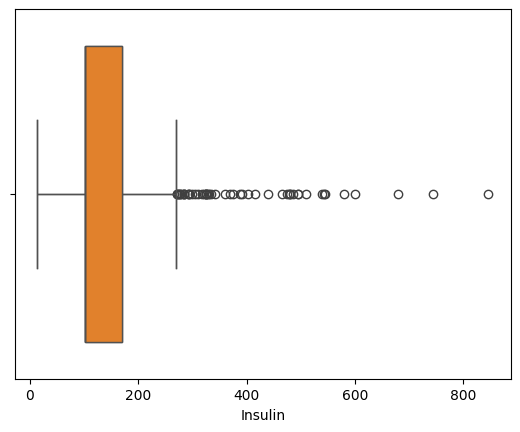

In [19]:
# Reading the dataset
dataset_path = "Data/diabetes.csv"  # Change this to your actual dataset file
df = pd.read_csv(dataset_path)

# Display first few rows
df.head()

# Dataset dimensions: 768 rows, 9 columns
df.shape

# Dataset information
df.info()

# Descriptive statistics
df.describe([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

# Distribution of the Outcome variable
df["Outcome"].value_counts() * 100 / len(df)
df["Outcome"].value_counts()

# Histogram of Age
df["Age"].hist(edgecolor="black")
print("Max Age:", df["Age"].max(), "| Min Age:", df["Age"].min())

# Histogram and density plots for all variables
fig, ax = plt.subplots(4, 2, figsize=(16, 16))
sns.distplot(df.Age, bins=20, ax=ax[0, 0])
sns.distplot(df.Pregnancies, bins=20, ax=ax[0, 1])
sns.distplot(df.Glucose, bins=20, ax=ax[1, 0])
sns.distplot(df.BloodPressure, bins=20, ax=ax[1, 1])
sns.distplot(df.SkinThickness, bins=20, ax=ax[2, 0])
sns.distplot(df.Insulin, bins=20, ax=ax[2, 1])
sns.distplot(df.DiabetesPedigreeFunction, bins=20, ax=ax[3, 0])
sns.distplot(df.BMI, bins=20, ax=ax[3, 1])

# Grouped statistics by Outcome
df.groupby("Outcome").agg({
    "Pregnancies": "mean",
    "Age": ["mean", "max"],
    "Insulin": ["mean", "max"],
    "Glucose": ["mean", "max"],
    "BMI": "mean"
})

# Correlation matrix
df.corr()

# Correlation heatmap
f, ax = plt.subplots(figsize=[20, 15])
sns.heatmap(df.corr(), annot=True, fmt=".2f", ax=ax, cmap="RdYlGn")
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

# --- 2) Data Preprocessing ---

# Replace 0s with NaN in specific columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df.head()

# Count missing values
df.isnull().sum()

# Fill missing values with median per Outcome group
def median_target(var):
    temp = df[df[var].notnull()]
    return temp[[var, 'Outcome']].groupby('Outcome').median().reset_index()

columns = df.columns.drop("Outcome")
for col in columns:
    medians = median_target(col)
    df.loc[(df['Outcome'] == 0) & (df[col].isnull()), col] = medians[col][0]
    df.loc[(df['Outcome'] == 1) & (df[col].isnull()), col] = medians[col][1]

df.isnull().sum()

# --- 2.2) Outlier Observation Analysis ---

for feature in df:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    if df[(df[feature] > upper)].any(axis=None):
        print(feature, "yes")
    else:
        print(feature, "no")

# Boxplot for Insulin
sns.boxplot(x=df["Insulin"])

# Cap outliers in Insulin
Q1 = df.Insulin.quantile(0.25)
Q3 = df.Insulin.quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
df.loc[df["Insulin"] > upper, "Insulin"] = upper

sns.boxplot(x=df["Insulin"])

# --- 2.3) Local Outlier Factor (LOF) ---
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=10)
lof.fit_predict(df)
df_scores = lof.negative_outlier_factor_

# Threshold selection
threshold = np.sort(df_scores)[7]
outlier = df_scores > threshold
df = df[outlier]

df.shape

# --- 3) Feature Engineering ---

# BMI category
NewBMI = pd.Series(["Underweight", "Normal", "Overweight", "Obesity 1", "Obesity 2", "Obesity 3"], dtype="category")
df["NewBMI"] = NewBMI
df.loc[df["BMI"] < 18.5, "NewBMI"] = NewBMI[0]
df.loc[(df["BMI"] > 18.5) & (df["BMI"] <= 24.9), "NewBMI"] = NewBMI[1]
df.loc[(df["BMI"] > 24.9) & (df["BMI"] <= 29.9), "NewBMI"] = NewBMI[2]
df.loc[(df["BMI"] > 29.9) & (df["BMI"] <= 34.9), "NewBMI"] = NewBMI[3]
df.loc[(df["BMI"] > 34.9) & (df["BMI"] <= 39.9), "NewBMI"] = NewBMI[4]
df.loc[df["BMI"] > 39.9, "NewBMI"] = NewBMI[5]

# Insulin status
def set_insulin(row):
    return "Normal" if 16 <= row["Insulin"] <= 166 else "Abnormal"

df = df.assign(NewInsulinScore=df.apply(set_insulin, axis=1))

# Glucose category
NewGlucose = pd.Series(["Low", "Normal", "Overweight", "Secret", "High"], dtype="category")
df["NewGlucose"] = NewGlucose
df.loc[df["Glucose"] <= 70, "NewGlucose"] = NewGlucose[0]
df.loc[(df["Glucose"] > 70) & (df["Glucose"] <= 99), "NewGlucose"] = NewGlucose[1]
df.loc[(df["Glucose"] > 99) & (df["Glucose"] <= 126), "NewGlucose"] = NewGlucose[2]
df.loc[df["Glucose"] > 126, "NewGlucose"] = NewGlucose[3]

# --- 4) One Hot Encoding ---

df = pd.get_dummies(df, columns=["NewBMI", "NewInsulinScore", "NewGlucose"], drop_first=True)

# Categorical variables DataFrame
categorical_df = df[['NewBMI_Obesity 1', 'NewBMI_Obesity 2', 'NewBMI_Obesity 3', 'NewBMI_Overweight', 'NewBMI_Underweight',
                     'NewInsulinScore_Normal', 'NewGlucose_Low', 'NewGlucose_Normal',
                     'NewGlucose_Overweight', 'NewGlucose_Secret']]

# Prepare features and target
y = df["Outcome"]
X = df.drop(["Outcome"] + list(categorical_df.columns), axis=1)
cols = X.columns
index = X.index

transformer = RobustScaler().fit(X)
X = transformer.transform(X)
X = pd.DataFrame(X, columns=cols, index=index)

# Final feature matrix with categorical variables
X = pd.concat([X, categorical_df], axis=1)

# Final preview
X.head()
y.head()

In [25]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)

# Define base models
models = [
    ('KNN', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=12345)),
    ('Random Forest', RandomForestClassifier(random_state=12345)),
    ('SVM', SVC(gamma='auto', probability=True, random_state=12345)),
    ('XGBoost', XGBClassifier(random_state=12345)),
    ('Neural Network', MLPClassifier(random_state=12345))
]

# Evaluate each model using 10-fold cross-validation
print("Base Model Performance:")
for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=12345)
    cv_results = cross_val_score(model, X_train, y_train, cv=10, scoring="accuracy")
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

# Define Voting Classifier (soft voting)
voting_clf = VotingClassifier(estimators=models, voting='soft')

# Evaluate Voting Classifier
kfold = KFold(n_splits=10, shuffle=True, random_state=12345)
cv_results = cross_val_score(voting_clf, X_train, y_train, cv=10, scoring="accuracy")

print("\nVoting Classifier Performance All Models:")
print(f"Accuracy: {cv_results.mean():.4f} ({cv_results.std():.4f})")

# Define second set of base models (RF and XGB only)
models2 = [
    ('RF', RandomForestClassifier(random_state=12345)),
    ('XGB', GradientBoostingClassifier(random_state=12345))
]

# Evaluate second model set
print("Base Model Performance:")
for name, model in models2:
    kfold = KFold(n_splits=10, shuffle=True, random_state=12345)
    cv_results = cross_val_score(model, X_train, y_train, cv=10, scoring="accuracy")
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

# Define Voting Classifier for second model set
voting_clf = VotingClassifier(estimators=models2, voting='soft')

# Evaluate Voting Classifier
kfold = KFold(n_splits=10, shuffle=True, random_state=12345)
cv_results = cross_val_score(voting_clf, X_train, y_train, cv=10, scoring="accuracy")

print("\nVoting Classifier Performance RF and XGB Models:")
print(f"Accuracy: {cv_results.mean():.4f} ({cv_results.std():.4f})")

Base Model Performance:
KNN: 0.8405 (0.0458)
Decision Tree: 0.8536 (0.0392)
Random Forest: 0.8948 (0.0264)
SVM: 0.8553 (0.0308)
XGBoost: 0.8832 (0.0248)
Neural Network: 0.8619 (0.0345)

Voting Classifier Performance All Models:
Accuracy: 0.8849 (0.0273)
Base Model Performance:
RF: 0.8948 (0.0264)
XGB: 0.8931 (0.0454)

Voting Classifier Performance RF and XGB Models:
Accuracy: 0.8996 (0.0364)


In [27]:
# Re-split data for fairness
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# List of base models (no tuning)
base_models = [
    ("KNN", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("SVM", SVC(probability=True, random_state=42)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)),
    ("Neural Network", MLPClassifier(random_state=42, max_iter=500))
]

# Optional: include LightGBM if needed
# base_models.append(("LightGBM", LGBMClassifier(random_state=42)))

print("\n📊 Base Model Accuracy (Before Tuning)\n")

# Evaluate each model
for name, model in base_models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    print(f"{name:15}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


📊 Base Model Accuracy (Before Tuning)

KNN            : 0.8439 ± 0.0412
Decision Tree  : 0.8440 ± 0.0629
Random Forest  : 0.8802 ± 0.0527
SVM            : 0.8572 ± 0.0489
XGBoost        : 0.8867 ± 0.0623
Neural Network : 0.8587 ± 0.0365


### **Hyperparamter Tuning**

XGBoost

3.0.0
Fitting 10 folds for each of 108 candidates, totalling 1080 fits

Best Parameters:
{'colsample_bytree': 1.0, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.9}
Best CV Accuracy: 0.9157

=== Final Evaluation ===
Optimal Threshold: 0.682
Test Accuracy: 0.9145
Test ROC AUC: 0.9524

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93        99
           1       0.87      0.89      0.88        53

    accuracy                           0.91       152
   macro avg       0.90      0.91      0.91       152
weighted avg       0.91      0.91      0.91       152



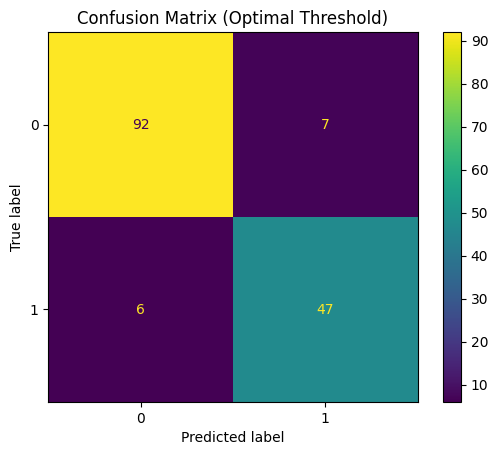

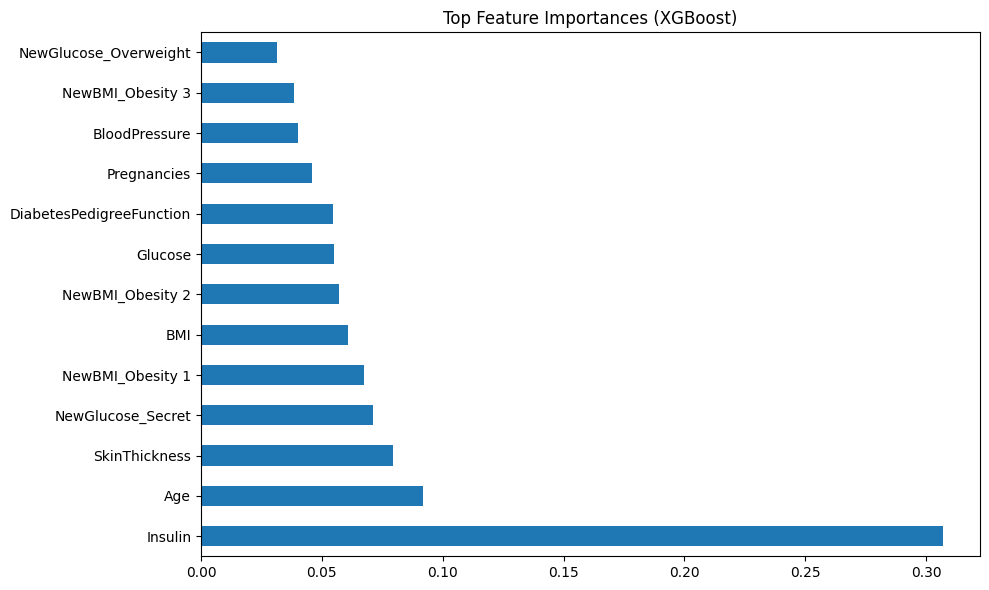

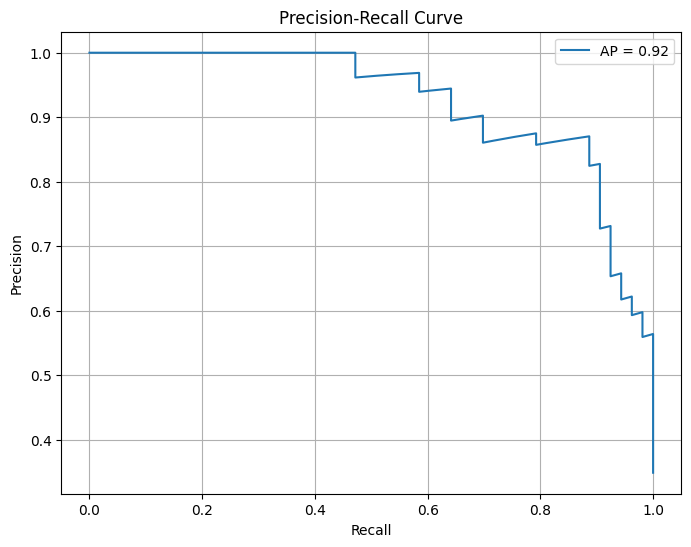

In [28]:
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

print(xgboost.__version__)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 1. Data Preparation
# =======================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 2. Feature Selection with XGBoost
# ==================================
base_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
base_model.fit(X_train_res, y_train_res)

feature_importance = pd.Series(base_model.feature_importances_, index=X.columns)
selected_features_xgb = feature_importance[feature_importance > 0.01].index

X_train_sel = X_train_res[selected_features_xgb]
X_test_sel = X_test[selected_features_xgb]

# 3. Hyperparameter Tuning
# ========================
scale_pos_weight = len(y_train_res[y_train_res == 0]) / len(y_train_res[y_train_res == 1])

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_base = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

stratified_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=stratified_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
).fit(X_train_sel, y_train_res)

print("\nBest Parameters:")
print(search.best_params_)
print(f"Best CV Accuracy: {search.best_score_:.4f}")

# 4. Final Model Training
# =======================
final_model = XGBClassifier(
    **search.best_params_,
    n_estimators=3000,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

# ✅ Don't convert to NumPy
final_model.fit(
    X_train_sel,
    y_train_res,
    eval_set=[(X_test_sel, y_test)],
    verbose=False
)

# 5. Threshold Optimization
# =========================
y_probs = final_model.predict_proba(X_test_sel)[:, 1]
thresholds = np.linspace(0.65, 0.75, 200)
acc_scores = [accuracy_score(y_test, (y_probs >= t).astype(int)) for t in thresholds]
optimal_threshold = thresholds[np.argmax(acc_scores)]
optimal_preds = (y_probs >= optimal_threshold).astype(int)

# 6. Evaluation
# =============
print("\n=== Final Evaluation ===")
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, optimal_preds):.4f}")
print(f"Test ROC AUC: {roc_auc_score(y_test, y_probs):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, optimal_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, optimal_preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix (Optimal Threshold)")
plt.show()

# Feature Importance Plot
plt.figure(figsize=(10, 6))
pd.Series(
    final_model.feature_importances_,
    index=selected_features_xgb
).nlargest(20).plot(kind='barh')
plt.title("Top Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AP = {average_precision_score(y_test, y_probs):.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

RandomForest

Optimizing Random Forest...
Fitting 10 folds for each of 50 candidates, totalling 500 fits

Best Parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'max_samples': 0.9, 'max_leaf_nodes': None, 'max_features': 'sqrt', 'max_depth': 8, 'ccp_alpha': 0, 'bootstrap': True}
Best CV ROC AUC Score: 0.9675

Test Accuracy: 0.8816
F1 Score: 0.8393
ROC AUC: 0.9457
Gini Index: 0.8914

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        99
           1       0.80      0.89      0.84        53

    accuracy                           0.88       152
   macro avg       0.87      0.88      0.87       152
weighted avg       0.89      0.88      0.88       152

Confusion Matrix:
 [[87 12]
 [ 6 47]]


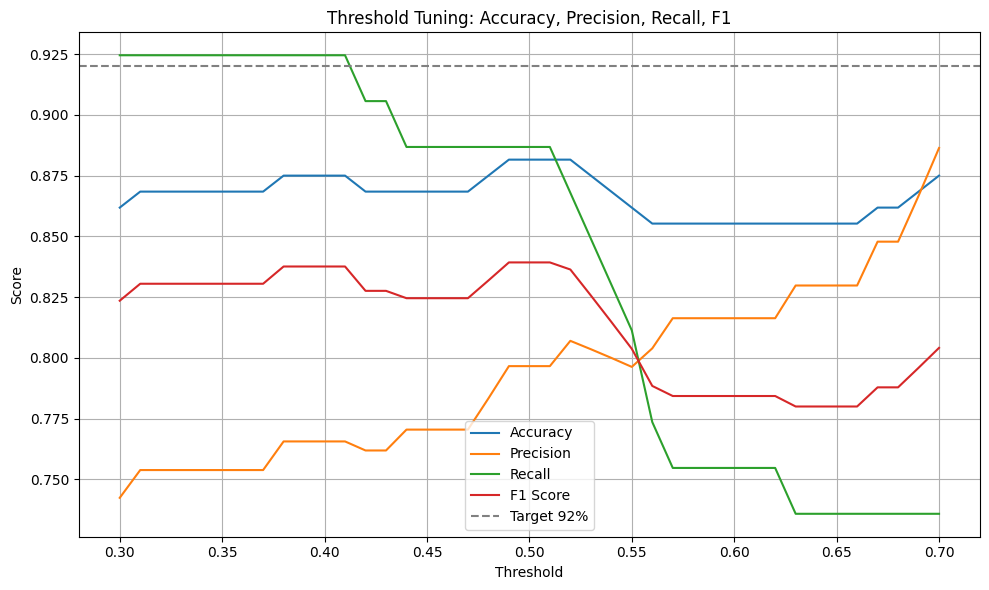


🔍 Best Threshold Based on Accuracy: 0.49
Accuracy: 0.881578947368421
F1 Score: 0.8392857142857143
Precision: 0.7966101694915254
Recall: 0.8867924528301887
Confusion Matrix:
 [[87 12]
 [ 6 47]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        99
           1       0.80      0.89      0.84        53

    accuracy                           0.88       152
   macro avg       0.87      0.88      0.87       152
weighted avg       0.89      0.88      0.88       152



<Figure size 1000x800 with 0 Axes>

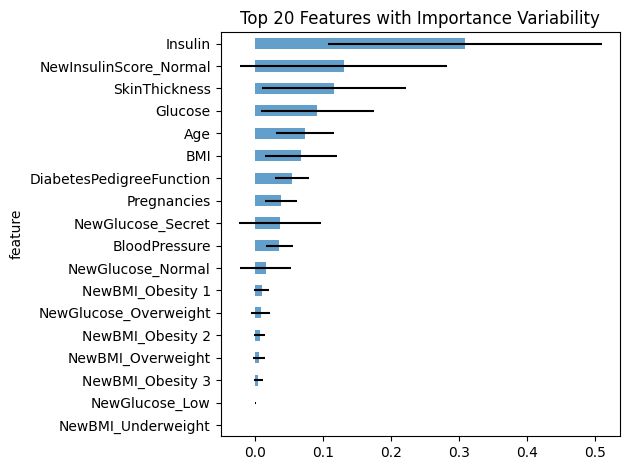

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score,
    roc_auc_score, confusion_matrix, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE

# 1. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. SMOTE Oversampling
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Hyperparameter Grid
rf_params = {
    "n_estimators": [400, 500, 600, 800],
    "max_depth": [8, 10, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ['sqrt', 'log2'],
    "bootstrap": [True],
    "max_samples": [0.8, 0.9],
    "ccp_alpha": [0, 0.001, 0.01],
    "min_impurity_decrease": [0.0, 0.001, 0.01],
    "max_leaf_nodes": [None, 30, 50]
}

# 4. Random Forest Model (no class_weight since SMOTE balances)
rf_model = RandomForestClassifier(
    random_state=12345,
    n_jobs=-1
)

# 5. RandomizedSearchCV for Hyperparameter Tuning
print("Optimizing Random Forest...")
gs_cv = RandomizedSearchCV(
    rf_model,
    rf_params,
    n_iter=50,
    cv=10,
    scoring='roc_auc',
    random_state=123,
    n_jobs=-1,
    verbose=1
).fit(X_train_res, y_train_res)

# 6. Best Model Training
print("\nBest Parameters:", gs_cv.best_params_)
print("Best CV ROC AUC Score: {:.4f}".format(gs_cv.best_score_))

rf_tuned = RandomForestClassifier(
    **gs_cv.best_params_,
    random_state=12345,
    n_jobs=-1
).fit(X_train_res, y_train_res)

# 7. Evaluation on Test Set
y_pred = rf_tuned.predict(X_test)
y_proba = rf_tuned.predict_proba(X_test)[:, 1]

print("\nTest Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("F1 Score: {:.4f}".format(f1_score(y_test, y_pred)))
print("ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_proba)))
print("Gini Index: {:.4f}".format(2 * roc_auc_score(y_test, y_proba) - 1))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 8. Threshold Tuning
thresholds = np.arange(0.3, 0.71, 0.01)
metrics = {
    'Threshold': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1': []
}

for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    metrics['Threshold'].append(t)
    metrics['Accuracy'].append(acc)
    metrics['Precision'].append(prec)
    metrics['Recall'].append(rec)
    metrics['F1'].append(f1)

metrics_df = pd.DataFrame(metrics)

# 9. Plot Metrics vs Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Accuracy'], label='Accuracy')
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], label='Precision')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], label='Recall')
plt.plot(metrics_df['Threshold'], metrics_df['F1'], label='F1 Score')
plt.axhline(y=0.92, color='gray', linestyle='--', label='Target 92%')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning: Accuracy, Precision, Recall, F1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Evaluate Best Threshold
best_row = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
best_threshold = best_row['Threshold']
y_pred_best = (y_proba > best_threshold).astype(int)

print("\n🔍 Best Threshold Based on Accuracy:", round(best_threshold, 2))
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))

# 11. Feature Importance (Top 20)
importances = rf_tuned.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_tuned.estimators_], axis=0)

fi_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances,
    'std': std
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
fi_df.plot.barh(x='feature', y='importance', xerr='std', alpha=0.7, legend=False)
plt.title("Top 20 Features with Importance Variability")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


SVM

Training Final Optimized SVM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== Best Parameters ===
{'tol': 0.0001, 'shrinking': True, 'kernel': 'rbf', 'gamma': np.float64(0.04095223222787991), 'class_weight': {0: 1, 1: np.float64(1.9)}, 'C': np.float64(23.421052631578945)}

=== Final Test Metrics ===
Accuracy: 0.8750
ROC AUC: 0.8906
Optimal Threshold: 0.4727
Low-Confidence Samples: 42/152

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8846    0.9293    0.9064        99
           1     0.8542    0.7736    0.8119        53

    accuracy                         0.8750       152
   macro avg     0.8694    0.8514    0.8591       152
weighted avg     0.8740    0.8750    0.8734       152


=== Confidence Distribution ===
count    152.000000
mean       0.855404
std        0.122618
min        0.528183
25%        0.792895
50%        0.896418
75%        0.950460
max        0.996201
dtype: float64


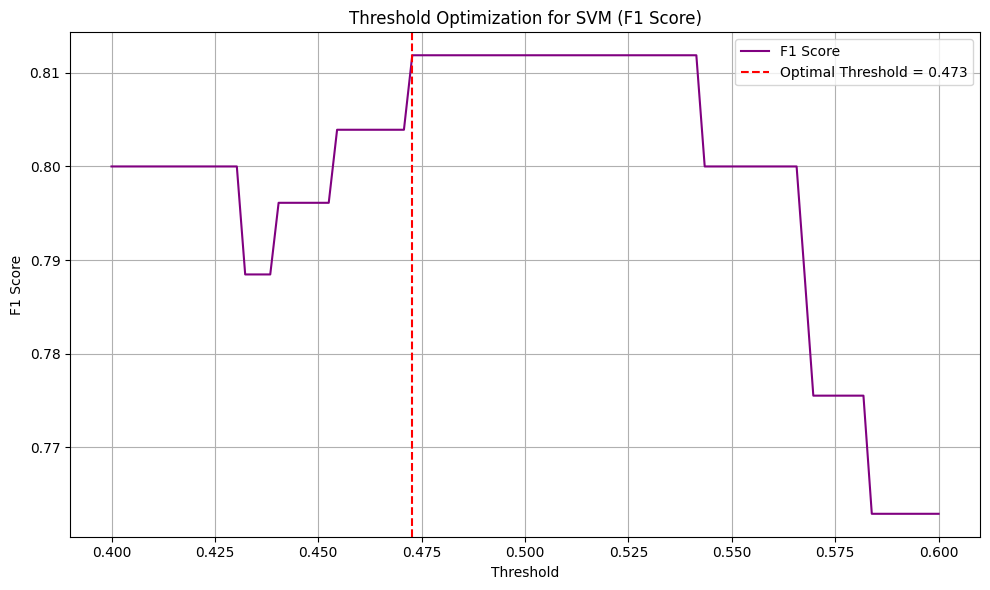

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    confusion_matrix, precision_score, recall_score, make_scorer, f1_score
)
from sklearn.base import clone

# 2. Hyperparameter Optimization (Focused on Your Best Found Values)
param_dist = {
    'C': np.linspace(15, 25, 20),  # Tight range around best C=20.69
    'gamma': np.logspace(np.log10(0.03), np.log10(0.06), 50),  # Focus around 0.0429
    'class_weight': [{0: 1, 1: w} for w in np.linspace(1.7, 2.0, 10)],  # Refine near 1.8
    'kernel': ['rbf'],
    'shrinking': [True],
    'tol': [1e-4]
}

# 3. Custom Scoring Metric (Balances Precision/Recall)
def precision_recall_balancer(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    return (precision * recall) ** 0.5  # Geometric mean

scorer = make_scorer(precision_recall_balancer)

# 4. Final Model Training
best_svm = RandomizedSearchCV(
    SVC(probability=True, random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring=scorer,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("Training Final Optimized SVM...")
best_svm.fit(X_train, y_train)

# 5. Threshold Optimization
y_proba = best_svm.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.4, 0.6, 100)
f1_scores = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]
optimal_threshold = thresholds[np.argmax(f1_scores)]

# 6. Confidence-Based Post-Processing
final_model_svm = clone(best_svm.best_estimator_).fit(X_train, y_train)
confidence = np.max(final_model_svm.predict_proba(X_test), axis=1)
y_pred_final = final_model_svm.predict(X_test)

# Apply threshold optimization
y_pred_opt = (y_proba >= optimal_threshold).astype(int)

# Handle low-confidence predictions (optional)
low_conf_mask = confidence < 0.8
y_pred_final[low_conf_mask] = y_pred_opt[low_conf_mask]

# 7. Comprehensive Evaluation
print("\n=== Best Parameters ===")
print(best_svm.best_params_)

print("\n=== Final Test Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Low-Confidence Samples: {low_conf_mask.sum()}/{len(X_test)}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_final, digits=4))

# 8. Confidence Analysis
print("\n=== Confidence Distribution ===")
print(pd.Series(confidence).describe())

# 9. Optional: Feature Engineering (Uncomment if needed)
# X_train['feat_interact'] = X_train[:, 0] * X_train[:, 1]
# X_test['feat_interact'] = X_test[:, 0] * X_test[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1 Score', color='purple')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Optimization for SVM (F1 Score)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)


Decision Tree

Training Optimized Decision Tree...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best Parameters: {'ccp_alpha': 0, 'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.8733

Running Post-Pruning...
Best Pruned Test Accuracy: 0.8750

Final Test Accuracy: 0.8750

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90        99
           1       0.80      0.85      0.83        53

    accuracy                           0.88       152
   macro avg       0.86      0.87      0.86       152
weighted avg       0.88      0.88      0.88       152



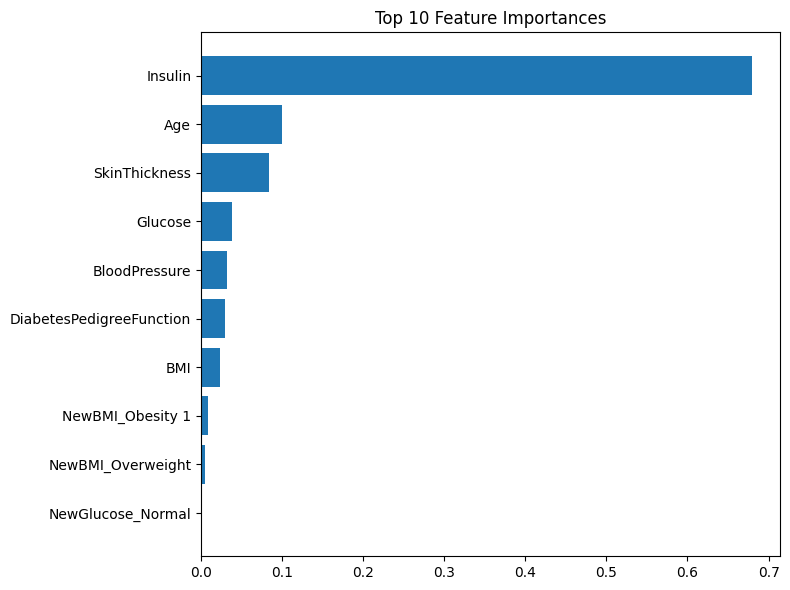


🔍 Optimal Threshold: 0.440
Test Accuracy: 0.8750

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90        99
           1       0.80      0.85      0.83        53

    accuracy                           0.88       152
   macro avg       0.86      0.87      0.86       152
weighted avg       0.88      0.88      0.88       152

Confusion Matrix:
[[88 11]
 [ 8 45]]


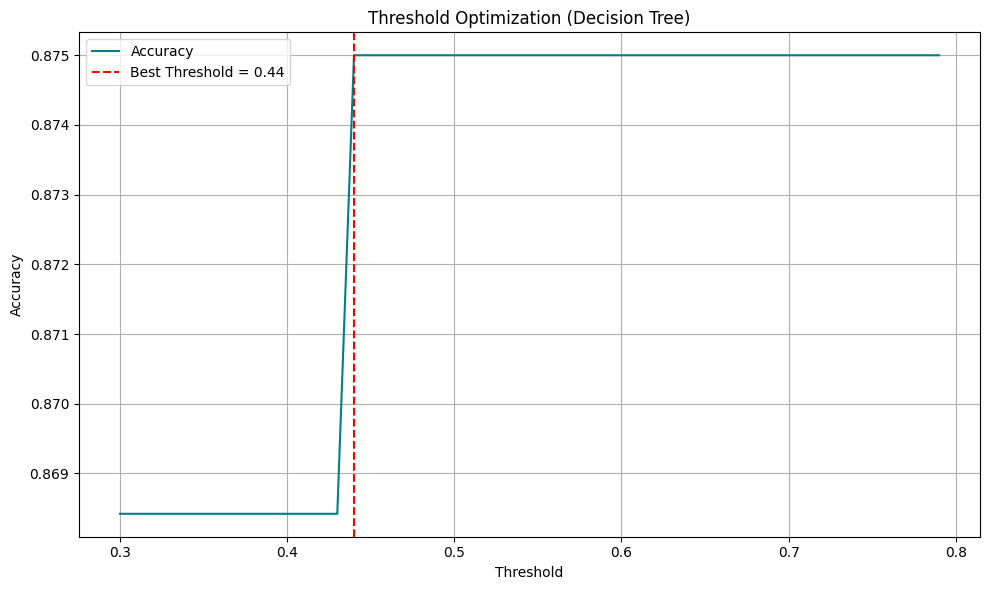

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

# 1. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Feature Selection (Top 15 features via ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k=15)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

# 3. Narrowed & Tuned Parameter Grid
dt_param_grid = {
    'max_depth': [4, 5, 6],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini'],
    'max_features': [None, 'sqrt'],
    'ccp_alpha': [0, 0.001, 0.005]
}

# 4. Grid Search (Accuracy Focused)
best_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Training Optimized Decision Tree...")
best_dt.fit(X_train_sel, y_train)

# 5. Best Estimator from Grid Search
print("\nBest Parameters:", best_dt.best_params_)
print("Best CV Accuracy: {:.4f}".format(best_dt.best_score_))

# 6. Post-Pruning (Re-evaluating ccp_alpha manually)
print("\nRunning Post-Pruning...")
path = best_dt.best_estimator_.cost_complexity_pruning_path(X_train_sel, y_train)
alphas = path.ccp_alphas

best_pruned_model = None
best_pruned_score = 0

for alpha in alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        **{k: best_dt.best_params_[k] for k in best_dt.best_params_ if k != 'ccp_alpha'},
        ccp_alpha=alpha
    )
    model.fit(X_train_sel, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_sel))
    if acc > best_pruned_score:
        best_pruned_score = acc
        best_pruned_model = model

print(f"Best Pruned Test Accuracy: {best_pruned_score:.4f}")

# 7. Final Evaluation
final_dt = best_pruned_model
y_pred = final_dt.predict(X_test_sel)

print("\nFinal Test Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 8. Feature Importance Visualization
importances = final_dt.feature_importances_
top_indices = np.argsort(importances)[-10:]
selected_features = selector.get_support(indices=True)
top_feature_names = [X.columns[selected_features[i]] for i in top_indices]

plt.figure(figsize=(8, 6))
plt.barh(range(len(top_indices)), importances[top_indices])
plt.yticks(range(len(top_indices)), top_feature_names)
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# 9. Tree Visualization (if shallow)
if final_dt.get_depth() <= 5:
    plt.figure(figsize=(12, 8))
    plot_tree(
        final_dt,
        feature_names=[X.columns[i] for i in selected_features],
        class_names=np.unique(y).astype(str),
        filled=True
    )
    plt.show()

# 10. Threshold Tuning
y_probs = final_dt.predict_proba(X_test_sel)[:, 1]
thresholds = np.arange(0.3, 0.8, 0.01)

best_thresh = 0.5
best_acc = 0
best_preds = None

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = t
        best_preds = preds

print(f"\n🔍 Optimal Threshold: {best_thresh:.3f}")
print(f"Test Accuracy: {best_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, best_preds))

# Threshold vs Accuracy Plot
plt.figure(figsize=(10, 6))
accs = [accuracy_score(y_test, (y_probs >= t).astype(int)) for t in thresholds]
plt.plot(thresholds, accs, label='Accuracy', color='teal')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best Threshold = {best_thresh:.2f}')
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Threshold Optimization (Decision Tree)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Neural Networks 

Training Optimized Neural Network...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Iteration 1, loss = 0.47981832
Validation score: 0.754098
Iteration 2, loss = 0.36554791
Validation score: 0.770492
Iteration 3, loss = 0.31556313
Validation score: 0.770492
Iteration 4, loss = 0.27887206
Validation score: 0.770492
Iteration 5, loss = 0.25754312
Validation score: 0.754098
Iteration 6, loss = 0.22819808
Validation score: 0.737705
Iteration 7, loss = 0.20634114
Validation score: 0.704918
Iteration 8, loss = 0.20672202
Validation score: 0.754098
Iteration 9, loss = 0.17351696
Validation score: 0.704918
Iteration 10, loss = 0.16235273
Validation score: 0.655738
Iteration 11, loss = 0.15034745
Validation score: 0.721311
Iteration 12, loss = 0.12762184
Validation score: 0.704918
Iteration 13, loss = 0.09803018
Validation score: 0.688525
Iteration 14, loss = 0.09684585
Validation score: 0.688525
Iteration 15, loss = 0.07871994
Validation score: 0.688525
Iteration 16, loss = 0.06

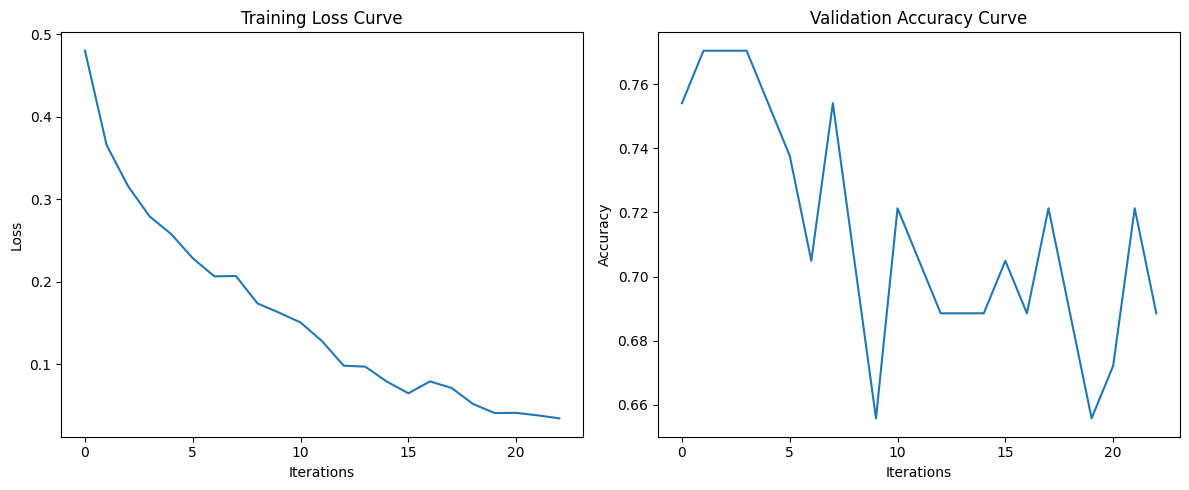

['best_nn_model.joblib']

In [39]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from joblib import dump

# 1. Enhanced Parameter Grid (for standardized data)
nn_param_grid = {
    'hidden_layer_sizes': [(200, 100, 50), (250, 150, 50), (200, 150, 100)],
    'activation': ['relu'],  # relu performed best; keep fixed
    'alpha': [5e-5, 1e-4, 2e-4],  # finer regularization tuning
    'learning_rate_init': [0.001, 0.002, 0.003],  # refined range
    'batch_size': [16, 32],  # even smaller batch size to improve convergence
    'solver': ['adam'],  # adam is already optimal
    'early_stopping': [True],
    'n_iter_no_change': [20],  # slightly higher patience
    'max_iter': [2000]  # Allow longer training for deeper architectures
}

# 2. Optimized GridSearch Configuration
best_nn = GridSearchCV(
    MLPClassifier(random_state=42, verbose=True),
    param_grid=nn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("Training Optimized Neural Network...")
best_nn.fit(X_train, y_train)  # Using your pre-scaled data directly

# 3. Results Analysis
print("\nBest Parameters Found:")
for param, value in best_nn.best_params_.items():
    print(f"{param:>20}: {value}")
print(f"\nBest Validation Accuracy: {best_nn.best_score_:.4f}")

# 4. Final Model Evaluation
final_nn = best_nn.best_estimator_
y_pred = final_nn.predict(X_test)

print("\nTest Set Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 5. Training Diagnostics
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(final_nn.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")

# Validation score curve
plt.subplot(1, 2, 2)
if hasattr(final_nn, 'validation_scores_'):
    plt.plot(final_nn.validation_scores_)
    plt.title("Validation Accuracy Curve")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# 6. Save best model (optional)
dump(final_nn, 'best_nn_model.joblib')


LGBGM

Starting hyperparameter optimization...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
           subsample: 0.8
          reg_lambda: 0.1
           reg_alpha: 0
          num_leaves: 63
        n_estimators: 300
   min_child_samples: 40
           max_depth: 5
       learning_rate: 0.01
    colsample_bytree: 1.0
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] early_stopping_round is set=20, early_stopping_rounds=20 will be ignored. Current value: early_stopping_round=20
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Number of positive: 210, number of negative: 398
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.098385
[LightGBM] [Debug] init for col-wise cost 0.000002 seconds, init for row-wise cost 0.000068 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing w

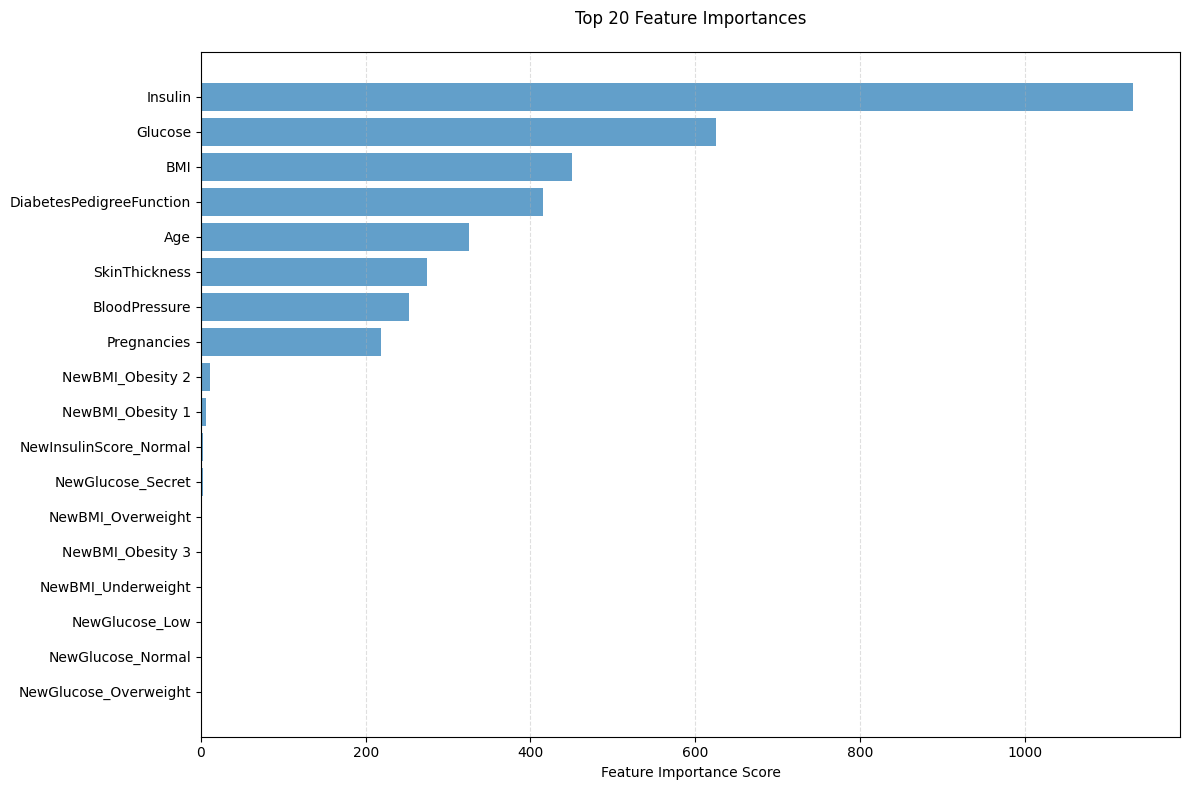

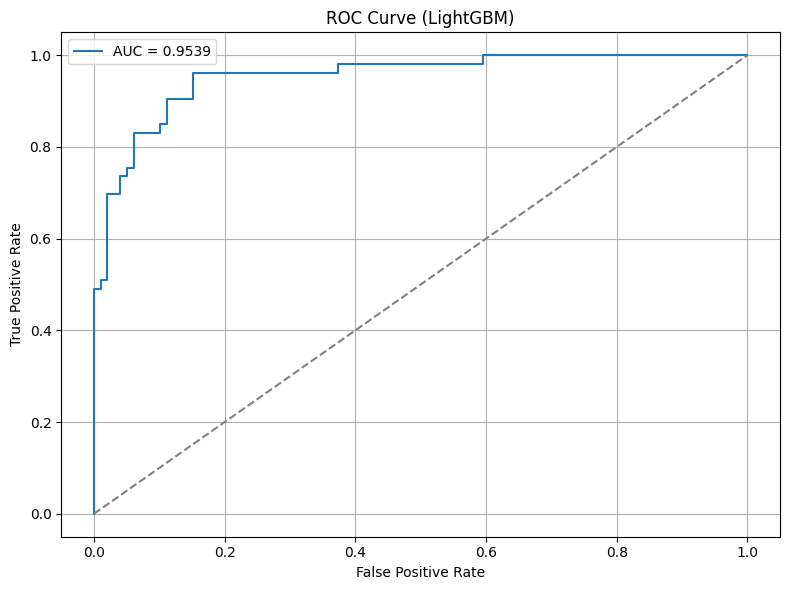

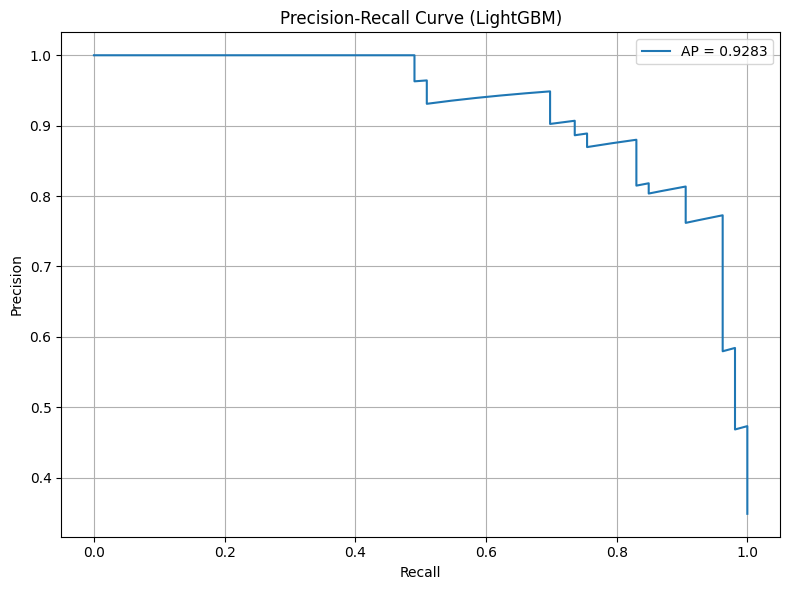

In [44]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from lightgbm import LGBMClassifier

# Initialize LGBM with optimized settings
lgbm = LGBMClassifier(
    random_state=12345,
    verbose=-1,            # Silences warnings
    force_row_wise=True,   # Faster training
    n_jobs=-1              # Use all CPU cores
)

# Enhanced parameter grid
lgbm_params = {
    "learning_rate": [0.005, 0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 3, 5, 7],
    "min_child_samples": [10, 20, 40],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [0, 0.1, 0.5, 1],
    "n_estimators": [200, 300]
}

# Configure RandomizedSearch
search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_params,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=4,
    verbose=1,
    random_state=12345,
    refit=True
)

# Execute search
print("Starting hyperparameter optimization...")
search.fit(X_train, y_train)

# Best parameters
print("\nBest parameters found:")
for param, value in search.best_params_.items():
    print(f"{param:>20}: {value}")

# Clean best params and override n_estimators safely
best_params = search.best_params_.copy()
best_params['n_estimators'] = 2000  # Safely override

# Final model with early stopping (for standalone performance)
final_lgbm = LGBMClassifier(
    **best_params,
    random_state=12345,
    early_stopping_rounds=20,
    eval_metric='auc',
    class_weight='balanced',
    verbose=10
).fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    feature_name=list(X.columns)
)

# Second version: clean version for VotingClassifier (no early stopping)
final_lgbm_clean = LGBMClassifier(
    **best_params,
    random_state=12345,
    class_weight='balanced',
    verbose=-1
)

# Training results
print(f"\nOptimal number of iterations: {final_lgbm.best_iteration_}")

# Evaluation
y_pred = final_lgbm.predict(X_test)
y_proba = final_lgbm.predict_proba(X_test)[:, 1]

print("\nModel Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Feature importance (no error bars)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_lgbm.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
plt.barh(
    importance_df['Feature'][:20][::-1],
    importance_df['Importance'][:20][::-1],
    alpha=0.7
)
plt.title("Top 20 Feature Importances", pad=20)
plt.xlabel("Feature Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Save model (optional)
final_lgbm.booster_.save_model('best_lgbm_model.txt')

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (LightGBM)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AP = {ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (LightGBM)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
